# 10. Causal Calibration of Forecasters

**The problem**

- I sell 10 muffins.
- I want to lift sales.
- I run a **discount** and an **ad campaign** about the discount.
- Both run on the same days. The sales data only sees their sum.

**The plan**

1. Pilot the discount in **another store**, on **one muffin only** ( to minimize profit loss), no ad campaign. Measure the lift with Synthetic Control.
2. In the main store, both campaigns run on all 10 muffins. Fit a hierarchical Bayes model — once without the pilot, once calibrated with it.
3. Compare: forecast accuracy and per-muffin attribution of discount vs ad campaign.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from optistock.causal import SyntheticControl, SyntheticControlPriors
from optistock.forecasting import Prior

## Step 1 — Pilot in the other store

- 10 muffins, 180 days of sales.
- Day 120: `muffin_1` goes on discount. Nothing else changes.
- The other 9 muffins are the donor pool for Synthetic Control.
- True discount lift: +10%.

In [2]:
rng = np.random.default_rng(7)
n_periods = 180
treatment_idx = 120
dates = pd.date_range('2024-01-01', periods=n_periods, freq='D')

shared_trend = np.linspace(0.0, 1.0, n_periods)
shared_season = 0.2 * np.sin(2 * np.pi * np.arange(n_periods) / 30.0)

def make_item(scale, offset, noise=0.05):
    series = offset + scale * shared_trend + scale * shared_season
    series = series + rng.normal(0, noise, n_periods)
    return series * 1000.0

# 10 muffins, mild jitter around (scale=1.0, offset=2.0).
item_specs = {
    'muffin_1':  (1.00, 2.0),
    'muffin_2':  (0.90, 1.8),
    'muffin_3':  (1.10, 2.2),
    'muffin_4':  (1.00, 1.9),
    'muffin_5':  (0.95, 2.1),
    'muffin_6':  (1.05, 2.0),
    'muffin_7':  (0.92, 1.95),
    'muffin_8':  (1.08, 2.05),
    'muffin_9':  (0.98, 1.85),
    'muffin_10': (1.03, 2.15),
}
df = pd.DataFrame({'date': dates})
for name, (scale, offset) in item_specs.items():
    df[name] = make_item(scale, offset)

true_lift = 0.10
df.loc[treatment_idx:, 'muffin_1'] *= 1 + true_lift

df.head()

,date,muffin_1,muffin_2,muffin_3,muffin_4,muffin_5,muffin_6,muffin_7,muffin_8,muffin_9,muffin_10
0,2024-01-01,2000.061508,1777.942740,2225.176043,1904.575372,2069.774508,2056.731525,1894.659629,2061.883862,1842.765940,2106.110826
1,2024-01-02,2062.106207,1817.053989,2345.429612,1954.718098,2127.731771,2165.168446,1979.917158,2122.226574,1848.344004,2155.506583
2,2024-01-03,2078.813620,1914.772591,2331.371179,1984.619303,2072.418439,2198.259303,2023.764517,2114.669650,1945.731824,2260.756931
3,2024-01-04,2089.787235,1905.791764,2350.539037,2013.100963,2288.448342,2130.073634,2081.877689,2234.584852,2004.292456,2242.739947
4,2024-01-05,2148.241795,1946.305618,2303.766936,2052.295151,2275.093872,2216.534057,2120.869736,2210.287389,1946.549699,2332.383808


### Pilot store — raw sales

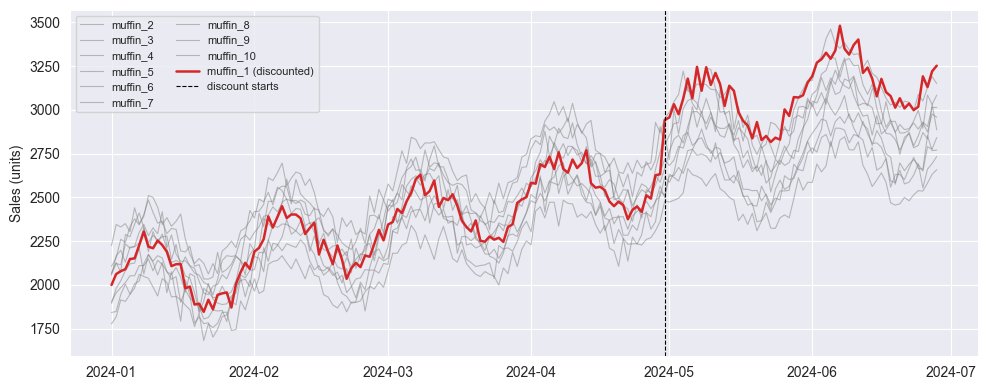

In [3]:
donor_cols = [f'muffin_{i}' for i in range(2, 11)]

fig, ax = plt.subplots(figsize=(10, 4))
for col in donor_cols:
    ax.plot(df['date'], df[col], color='grey', alpha=0.5, lw=0.8, label=col)
ax.plot(df['date'], df['muffin_1'], color='C3', lw=1.8, label='muffin_1 (discounted)')
ax.axvline(dates[treatment_idx], color='k', ls='--', lw=0.8, label='discount starts')
ax.set_ylabel('Sales (units)')
ax.legend(loc='upper left', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Fit Synthetic Control

- Treated: `muffin_1`. Donors: `muffin_2` … `muffin_10`.
- Treatment date: day 120.

In [4]:
sc = SyntheticControl(
    data=df,
    treated_item='muffin_1',
    donor_items=donor_cols,
    treatment_date=dates[treatment_idx],
    intervention_name='discount',
)
print(f'Internal scaler (panel max): {sc._scale:,.1f}')

Internal scaler (panel max): 3,480.7


In [5]:
idata = sc.fit(samples=1000, tune=1000, chains=2, random_seed=7)

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [beta, y_hat, y_hat_sigma]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


In [6]:
az.summary(idata, var_names=['beta', 'y_hat_sigma'], hdi_prob=0.94, round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta[muffin_1, muffin_2]",0.089,0.049,0.000,0.170,0.001,0.001,915.056,610.978,1.000
"beta[muffin_1, muffin_3]",0.098,0.051,0.002,0.181,0.001,0.001,1092.347,743.219,1.001
"beta[muffin_1, muffin_4]",0.229,0.077,0.069,0.361,0.002,0.002,1132.933,868.679,1.001
"beta[muffin_1, muffin_5]",0.048,0.038,0.000,0.117,0.001,0.001,1272.764,899.123,1.002
"beta[muffin_1, muffin_6]",0.214,0.080,0.075,0.366,0.003,0.002,919.311,705.163,1.005
"beta[muffin_1, muffin_7]",0.077,0.053,0.000,0.171,0.001,0.001,921.484,605.007,1.000
"beta[muffin_1, muffin_8]",0.126,0.064,0.002,0.231,0.002,0.002,973.995,517.281,1.002
"beta[muffin_1, muffin_9]",0.049,0.039,0.000,0.118,0.001,0.001,821.158,489.862,1.004
"beta[muffin_1, muffin_10]",0.070,0.047,0.000,0.153,0.001,0.001,2025.256,1339.057,1.003
y_hat_sigma[muffin_1],0.013,0.001,0.012,0.015,0.000,0.000,1296.963,1120.535,1.004


## Pilot result

The discount lifted `muffin_1` sales by ~10%. Save this number — it becomes the calibration in step 2.

In [7]:
effect = sc.summary()
print(effect)
print()
print(f'True planted lift: +{true_lift * 100:.1f}%')
print(f'Cumulative absolute lift: {effect.mean_abs_lift:,.0f} units')

discount changed sales of muffin_1 by +9.6% [94% HDI: +9.1%, +10.0%]

True planted lift: +10.0%
Cumulative absolute lift: 16,267 units


### Actual vs counterfactual

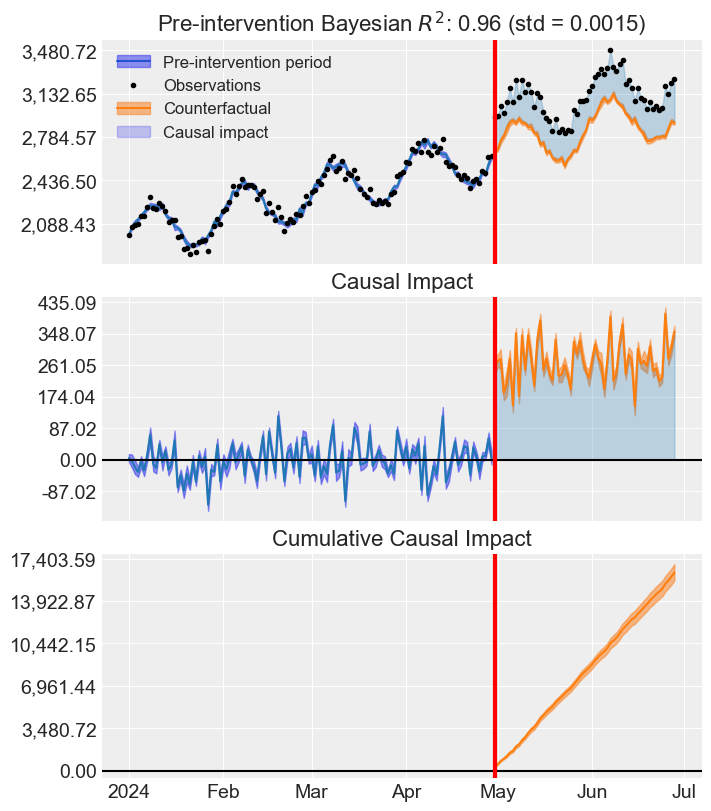

In [8]:
fig, axes = sc.plot()
plt.show()

### Donor weights

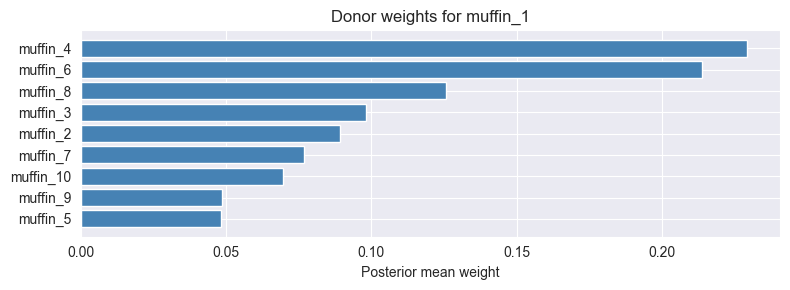

In [9]:
fig, ax = sc.plot_weights()
plt.show()

## Step 2 — Main store: both campaigns at once

- Main store. 10 muffins. 180 days train, 60 days test.
- Day 120: **discount** *and* **ad campaign** launch together, on every muffin, for 60 days.
- The time series sees only the **sum** of the two lifts per muffin.
- Calibration: feed the pilot result on `muffin_1`'s discount in as a `LiftConstraint`.

We fit two models on the same data:

- **Uncalibrated** — every muffin's `(β_discount, β_ad_campaign)` is a diagonal ridge. The hyperprior `μ_discount` is itself on a ridge — pooling alone cannot split them.
- **Calibrated** — one pin on `muffin_1`'s discount. That pin anchors `μ_discount`, partial pooling pulls every muffin's discount coefficient toward it, and each ad-campaign coefficient is then deduced from the per-muffin sum.

In [10]:
from optistock.causal import LiftConstraint
from optistock.forecasting import HierarchicalBayesTimeSeries

# Pilot result on muffin_1's discount, reused as a calibration constraint.
constraint = LiftConstraint.from_synthetic_control(
    sc, event_name="discount", item="muffin_1"
)
print("Calibration constraint:", constraint)

# --- Main store panel: every muffin runs discount + ad_campaign simultaneously ---
# Per-muffin TRUE lifts drawn from population distributions.
true_discount_pop_mean = 0.10
true_discount_pop_sd = 0.02
true_ad_pop_mean = 0.05
true_ad_pop_sd = 0.015

rng_cal = np.random.default_rng(42)
items_cal = [f"muffin_{i}" for i in range(1, 11)]
item_true_discount = {
    item: float(rng_cal.normal(true_discount_pop_mean, true_discount_pop_sd))
    for item in items_cal
}
item_true_ad = {
    item: float(rng_cal.normal(true_ad_pop_mean, true_ad_pop_sd))
    for item in items_cal
}

print("\nPer-muffin true lifts:")
for item in items_cal:
    print(
        f"  {item}: discount={item_true_discount[item]:+.2%}, ad_campaign={item_true_ad[item]:+.2%}"
    )

# Panel: 180 days training + 60 days test.
n_train_cal = 180
n_test_cal = 60
n_total_cal = n_train_cal + n_test_cal
treatment_idx_cal = 120
pilot_window = slice(treatment_idx_cal, n_train_cal)
dates_cal = pd.date_range("2025-01-01", periods=n_total_cal, freq="D")

trend_cal = np.linspace(0.0, 1.0, n_total_cal)
season_cal = 0.2 * np.sin(2 * np.pi * np.arange(n_total_cal) / 30.0)


def make_item_cal(scale, offset, noise=0.05):
    series = offset + scale * trend_cal + scale * season_cal
    series = series + rng_cal.normal(0, noise, n_total_cal)
    return series * 1000.0


item_specs_cal = {
    "muffin_1":  (1.00, 2.0),
    "muffin_2":  (0.90, 1.8),
    "muffin_3":  (1.10, 2.2),
    "muffin_4":  (1.00, 1.9),
    "muffin_5":  (0.95, 2.1),
    "muffin_6":  (1.05, 2.0),
    "muffin_7":  (0.92, 1.95),
    "muffin_8":  (1.08, 2.05),
    "muffin_9":  (0.98, 1.85),
    "muffin_10": (1.03, 2.15),
}
panel_cal = pd.DataFrame({"date": dates_cal})
for item, (scale, offset) in item_specs_cal.items():
    panel_cal[item] = make_item_cal(scale, offset)

# Every muffin gets BOTH events on the pilot dates (joint lift = discount + ad_campaign).
for item in items_cal:
    combined = item_true_discount[item] + item_true_ad[item]
    panel_cal.loc[pilot_window, item] *= 1 + combined

# Train / test split — test window has no campaigns running.
df_train_cal = panel_cal.iloc[:n_train_cal].reset_index(drop=True)
df_test_cal = panel_cal.iloc[n_train_cal:].reset_index(drop=True)

# Both events fire on the same pilot dates for every muffin.
pilot_dates_cal = list(dates_cal[treatment_idx_cal:n_train_cal])
events_cal = {
    "discount": pilot_dates_cal,
    "ad_campaign": pilot_dates_cal,
}

seasonal_cal = {"weekly": (7, 2), "monthly": (30.5, 2)}

# Uncalibrated — only the joint per-muffin lift is identified by the data.
htm_uncal = HierarchicalBayesTimeSeries(
    data=df_train_cal,
    date_col="date",
    seasonal_config=seasonal_cal,
)
htm_uncal.create_events(events_cal)
htm_uncal.fit(samples=500, chains=2)

# Calibrated — single LiftConstraint on (muffin_1, discount). Pinning propagates
# via the hyperprior pool to every muffin.
htm_cal = HierarchicalBayesTimeSeries(
    data=df_train_cal,
    date_col="date",
    seasonal_config=seasonal_cal,
    lift_constraints=[constraint],
)
htm_cal.create_events(events_cal)
htm_cal.fit(samples=500, chains=2)

# Forecast — test window has no events.
df_future_cal = pd.DataFrame({"date": df_test_cal["date"].values})
fc_uncal = htm_uncal.forecast({"df_future": df_future_cal})
fc_cal = htm_cal.forecast({"df_future": df_future_cal})

Calibration constraint: LiftConstraint(event_name='discount', mean_abs_lift=271.10905952738733, sigma_abs_lift=5.974730811587291, item='muffin_1')

Per-muffin true lifts:
  muffin_1: discount=+10.61%, ad_campaign=+6.32%
  muffin_2: discount=+7.92%, ad_campaign=+6.17%
  muffin_3: discount=+11.50%, ad_campaign=+5.10%
  muffin_4: discount=+11.88%, ad_campaign=+6.69%
  muffin_5: discount=+6.10%, ad_campaign=+5.70%
  muffin_6: discount=+7.40%, ad_campaign=+3.71%
  muffin_7: discount=+10.26%, ad_campaign=+5.55%
  muffin_8: discount=+9.37%, ad_campaign=+3.56%
  muffin_9: discount=+9.97%, ad_campaign=+6.32%
  muffin_10: discount=+8.29%, ad_campaign=+4.93%


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.02,255
,1500,0,0.03,1023


Sampling: [y]


Output()

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.02,1023
,1500,0,0.07,127


Sampling: [lift_obs_muffin_1_discount, y]


Output()

## Forecasts on the no-event window — the control

- Test window has no campaigns running.
- The per-muffin sum `β_discount + β_ad_campaign` is identified by the data, so both models capture the training-window lift correctly.
- Trend / seasonality care about what's *left* after that sum — they don't care about the split.
- Expect a near-tie. That's the point: calibration only changes what it should.

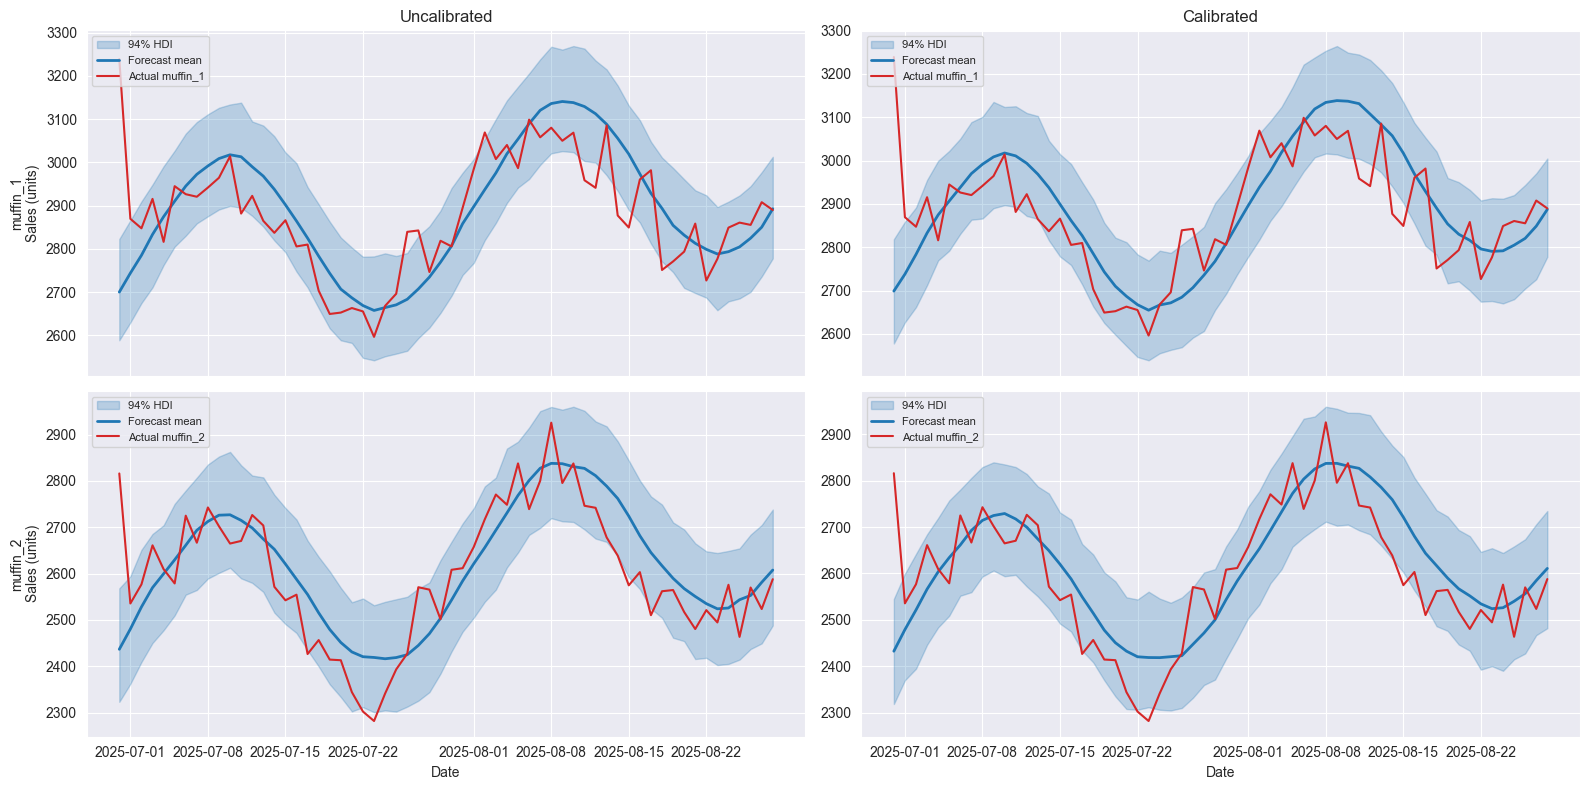

In [16]:
def predict_summary(forecast_idata, item, scaler):
    y = forecast_idata.predictions['y'].sel(item=item) * scaler
    mean = y.mean(dim=('chain', 'draw')).values
    hdi = az.hdi(y, hdi_prob=0.94)['y'].values
    return mean, hdi

focus_items = ['muffin_1', 'muffin_2']
test_dates = df_test_cal['date'].to_numpy()

fig, axes = plt.subplots(len(focus_items), 2, figsize=(16, 4 * len(focus_items)), sharex=True)
for r, item in enumerate(focus_items):
    actual = df_test_cal[item].to_numpy()
    for c, (fc, m, title) in enumerate([
        (fc_uncal, htm_uncal, 'Uncalibrated'),
        (fc_cal,   htm_cal,   'Calibrated'),
    ]):
        mean, hdi = predict_summary(fc, item, m.max_scaler)
        ax = axes[r, c]
        ax.fill_between(test_dates, hdi[:, 0], hdi[:, 1], color='C0', alpha=0.25, label='94% HDI')
        ax.plot(test_dates, mean, color='C0', lw=2, label='Forecast mean')
        ax.plot(test_dates, actual, color='C3', lw=1.5, label=f'Actual {item}')
        if r == 0:
            ax.set_title(title)
        ax.set_ylabel(f'{item}\nSales (units)' if c == 0 else '')
        if r == len(focus_items) - 1:
            ax.set_xlabel('Date')
        ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
def rmse(yhat, y):
    return float(np.sqrt(np.mean((yhat - y) ** 2)))

def mean_hdi_width(hdi):
    return float(np.mean(hdi[:, 1] - hdi[:, 0]))

rows = []
for item in htm_cal.items:
    actual = df_test_cal[item].to_numpy()
    mean_u, hdi_u = predict_summary(fc_uncal, item, htm_uncal.max_scaler)
    mean_c, hdi_c = predict_summary(fc_cal,   item, htm_cal.max_scaler)
    rows.append({
        'item': item,
        'RMSE uncal': rmse(mean_u, actual),
        'RMSE cal':   rmse(mean_c, actual),
        'HDIw uncal': mean_hdi_width(hdi_u),
        'HDIw cal':   mean_hdi_width(hdi_c),
    })
summary = pd.DataFrame(rows).set_index('item')
summary['RMSE Δ'] = (1 - summary['RMSE cal'] / summary['RMSE uncal']).map('{:+.0%}'.format)
summary['HDIw Δ'] = (1 - summary['HDIw cal'] / summary['HDIw uncal']).map('{:+.0%}'.format)
summary.round(0)

,RMSE uncal,RMSE cal,HDIw uncal,HDIw cal,RMSE Δ,HDIw Δ
item,,,,,,
muffin_1,105.0,105.0,238.0,236.0,+0%,+1%
muffin_2,85.0,85.0,242.0,243.0,+0%,-0%
muffin_3,114.0,114.0,240.0,240.0,-0%,+0%
muffin_4,101.0,101.0,239.0,238.0,+0%,+0%
muffin_5,95.0,95.0,240.0,239.0,-0%,+0%
muffin_6,95.0,96.0,237.0,237.0,-1%,-0%
muffin_7,89.0,89.0,240.0,239.0,+0%,+1%
muffin_8,105.0,105.0,239.0,238.0,-0%,+1%
muffin_9,98.0,98.0,238.0,238.0,-0%,+0%


## Per-muffin discount vs ad-campaign coefficients

This is the payoff.

- Each muffin's time series sees only `β_discount + β_ad_campaign`. Individual coefficients are wide and overlapping.
- One pin on `muffin_1`'s discount propagates through the hierarchy:
  1. `β_discount[muffin_1]` is fixed by the pilot.
  2. `μ_discount` is pulled off the diagonal.
  3. Every other muffin's `β_discount[i]` is pulled toward `μ_discount` via partial pooling.
  4. Each `β_ad_campaign[i]` is deduced from the per-muffin sum.

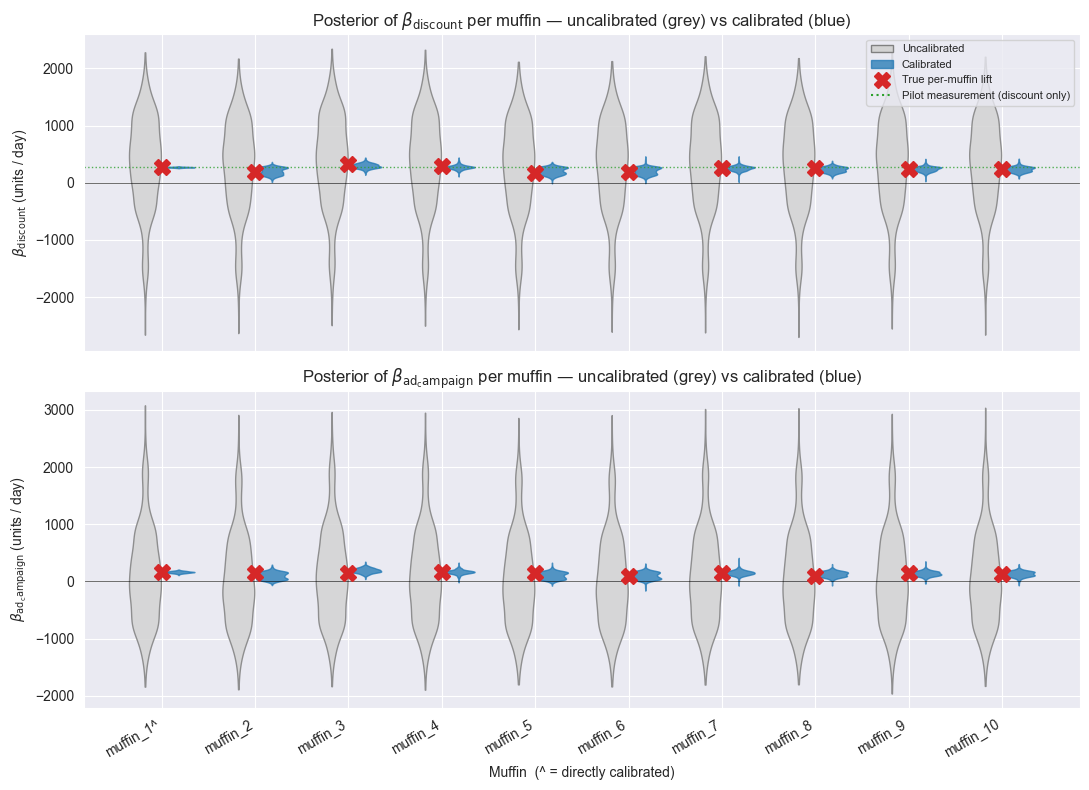

In [13]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

scaler = htm_cal.max_scaler


def beta(idata, event_name, item):
    return (
        idata.posterior["beta_event"].sel(event=event_name, item=item).values.ravel()
        * scaler
    )


# True per-muffin absolute lifts in units / day.
true_abs = {}
for item in items_cal:
    obs = df_train_cal.iloc[pilot_window][item].mean()
    base = obs / (1 + item_true_discount[item] + item_true_ad[item])
    true_abs[item] = {
        "discount": base * item_true_discount[item],
        "ad_campaign": base * item_true_ad[item],
    }

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
positions = np.arange(len(items_cal))
width = 0.36

for ax, event_name in zip(axes, ["discount", "ad_campaign"]):
    data_u = [beta(htm_uncal.idata, event_name, item) for item in items_cal]
    data_c = [beta(htm_cal.idata, event_name, item) for item in items_cal]

    vp_u = ax.violinplot(
        data_u,
        positions=positions - width / 2,
        widths=width * 0.95,
        showmeans=False,
        showextrema=False,
    )
    for body in vp_u["bodies"]:
        body.set_facecolor("lightgrey")
        body.set_edgecolor("grey")
        body.set_alpha(0.85)

    vp_c = ax.violinplot(
        data_c,
        positions=positions + width / 2,
        widths=width * 0.95,
        showmeans=False,
        showextrema=False,
    )
    for body in vp_c["bodies"]:
        body.set_facecolor("C0")
        body.set_edgecolor("C0")
        body.set_alpha(0.75)

    for i, item in enumerate(items_cal):
        ax.plot(
            positions[i], true_abs[item][event_name], "X", color="C3", ms=11, zorder=5
        )

    if event_name == "discount":
        ax.axhline(constraint.mean_abs_lift, color="C2", ls=":", lw=1.0, alpha=0.8)

    ax.axhline(0, color="k", lw=0.4)
    ax.set_ylabel(rf"$\beta_{{\mathrm{{{event_name}}}}}$ (units / day)")
    ax.set_title(
        rf"Posterior of $\beta_{{\mathrm{{{event_name}}}}}$ per muffin — uncalibrated (grey) vs calibrated (blue)"
    )

handles = [
    Patch(facecolor="lightgrey", edgecolor="grey", label="Uncalibrated"),
    Patch(facecolor="C0", edgecolor="C0", alpha=0.75, label="Calibrated"),
    Line2D([0], [0], marker="X", color="C3", ls="", ms=11, label="True per-muffin lift"),
    Line2D([0], [0], ls=":", color="C2", label="Pilot measurement (discount only)"),
]
axes[0].legend(handles=handles, fontsize=8, loc="upper right")

axes[1].set_xticks(positions)
axes[1].set_xticklabels([f"{i}{'^' if i == 'muffin_1' else ''}" for i in items_cal], rotation=30, ha='right')
axes[1].set_xlabel("Muffin  (^ = directly calibrated)")
plt.tight_layout()
plt.show()

## The sum is what the data identifies

Same posteriors as above, but plotted as `β_discount + β_ad_campaign` per muffin.

- Every violin collapses onto the true total lift — uncalibrated *and* calibrated.
- The data identifies the combined effect tightly. It has no purchase on the split.
- Calibration's whole job is taking that well-identified sum and splitting it correctly.

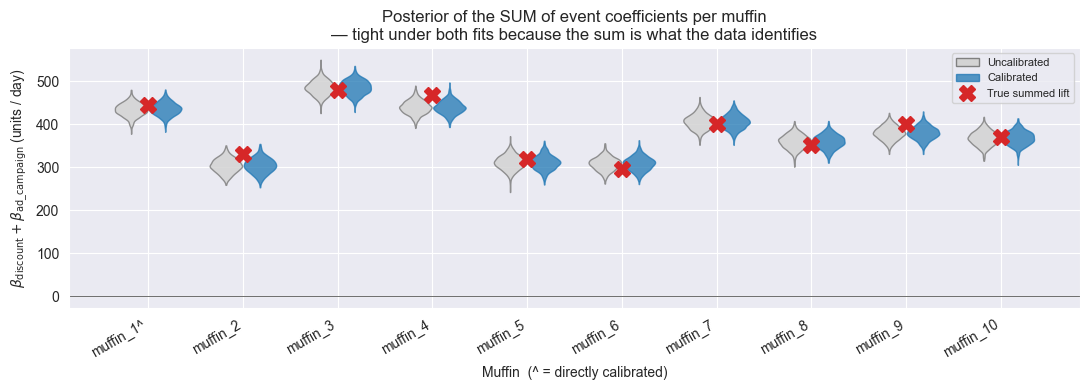

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
positions = np.arange(len(items_cal))
width = 0.36


def beta_sum(idata, item):
    d = idata.posterior["beta_event"].sel(event="discount", item=item).values.ravel()
    a = idata.posterior["beta_event"].sel(event="ad_campaign", item=item).values.ravel()
    return (d + a) * scaler


data_u = [beta_sum(htm_uncal.idata, item) for item in items_cal]
data_c = [beta_sum(htm_cal.idata, item) for item in items_cal]

vp_u = ax.violinplot(
    data_u,
    positions=positions - width / 2,
    widths=width * 0.95,
    showmeans=False,
    showextrema=False,
)
for body in vp_u["bodies"]:
    body.set_facecolor("lightgrey")
    body.set_edgecolor("grey")
    body.set_alpha(0.85)

vp_c = ax.violinplot(
    data_c,
    positions=positions + width / 2,
    widths=width * 0.95,
    showmeans=False,
    showextrema=False,
)
for body in vp_c["bodies"]:
    body.set_facecolor("C0")
    body.set_edgecolor("C0")
    body.set_alpha(0.75)

for i, item in enumerate(items_cal):
    true_sum = true_abs[item]["discount"] + true_abs[item]["ad_campaign"]
    ax.plot(positions[i], true_sum, "X", color="C3", ms=11, zorder=5)

ax.axhline(0, color="k", lw=0.4)
ax.set_xticks(positions)
ax.set_xticklabels([f"{i}{'^' if i == 'muffin_1' else ''}" for i in items_cal], rotation=30, ha='right')
ax.set_xlabel("Muffin  (^ = directly calibrated)")
ax.set_ylabel(r"$\beta_{\mathrm{discount}} + \beta_{\mathrm{ad\_campaign}}$ (units / day)")
ax.set_title(
    "Posterior of the SUM of event coefficients per muffin\n"
    "— tight under both fits because the sum is what the data identifies"
)

handles = [
    Patch(facecolor="lightgrey", edgecolor="grey", label="Uncalibrated"),
    Patch(facecolor="C0", edgecolor="C0", alpha=0.75, label="Calibrated"),
    Line2D([0], [0], marker="X", color="C3", ls="", ms=11, label="True summed lift"),
]
ax.legend(handles=handles, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


## Takeaway

- Without calibration: aggregate forecast looks fine, attribution is mush.
- One small pilot, on one muffin, in one store → one `LiftConstraint` → clean per-muffin attribution of discount vs ad campaign across the whole catalogue.
- The hierarchical structure is what makes that propagation work. The pin is on `muffin_1`, but every muffin benefits.